In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("breast_cancer.csv")
df.head(3)

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,outcome
0,0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [9]:
df = df.drop(df.columns[0], axis=1)  # drop first column


In [11]:
print(df.info())
print("\n Is NULL Item ?",df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [13]:
print("Is Duplicate Item?",df.duplicated().sum()) #checking duplicate items
print("Unique Items \n",df.nunique())

Is Duplicate Item? 0
Unique Items 
 mean radius                456
mean texture               479
mean perimeter             522
mean area                  539
mean smoothness            474
mean compactness           537
mean concavity             537
mean concave points        542
mean symmetry              432
mean fractal dimension     499
radius error               540
texture error              519
perimeter error            533
area error                 528
smoothness error           547
compactness error          541
concavity error            533
concave points error       507
symmetry error             498
fractal dimension error    545
worst radius               457
worst texture              511
worst perimeter            514
worst area                 544
worst smoothness           411
worst compactness          529
worst concavity            539
worst concave points       492
worst symmetry             500
worst fractal dimension    535
outcome                      2
dty

In [15]:
# Count how many cancer vs no-cancer patients
print(df['outcome'].value_counts())
# 1 = Benign (no cancer) → 357 patients
# 0 = Malignant (cancer) → 212 patients

outcome
1    357
0    212
Name: count, dtype: int64


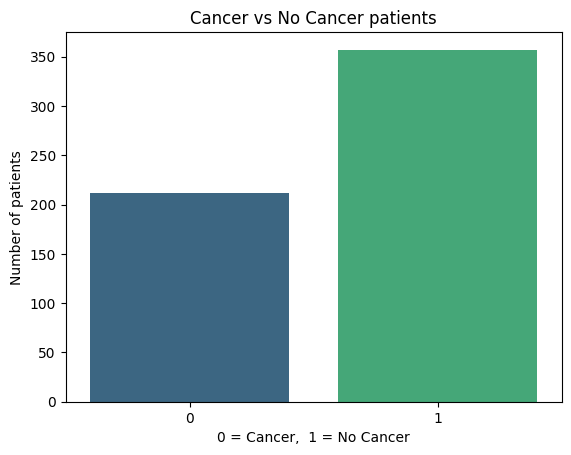

In [17]:
# Visualize it as a bar chart
sns.countplot(x='outcome', data=df, palette='viridis')
plt.title('Cancer vs No Cancer patients')
plt.xlabel('0 = Cancer,  1 = No Cancer')
plt.ylabel('Number of patients')
plt.show()

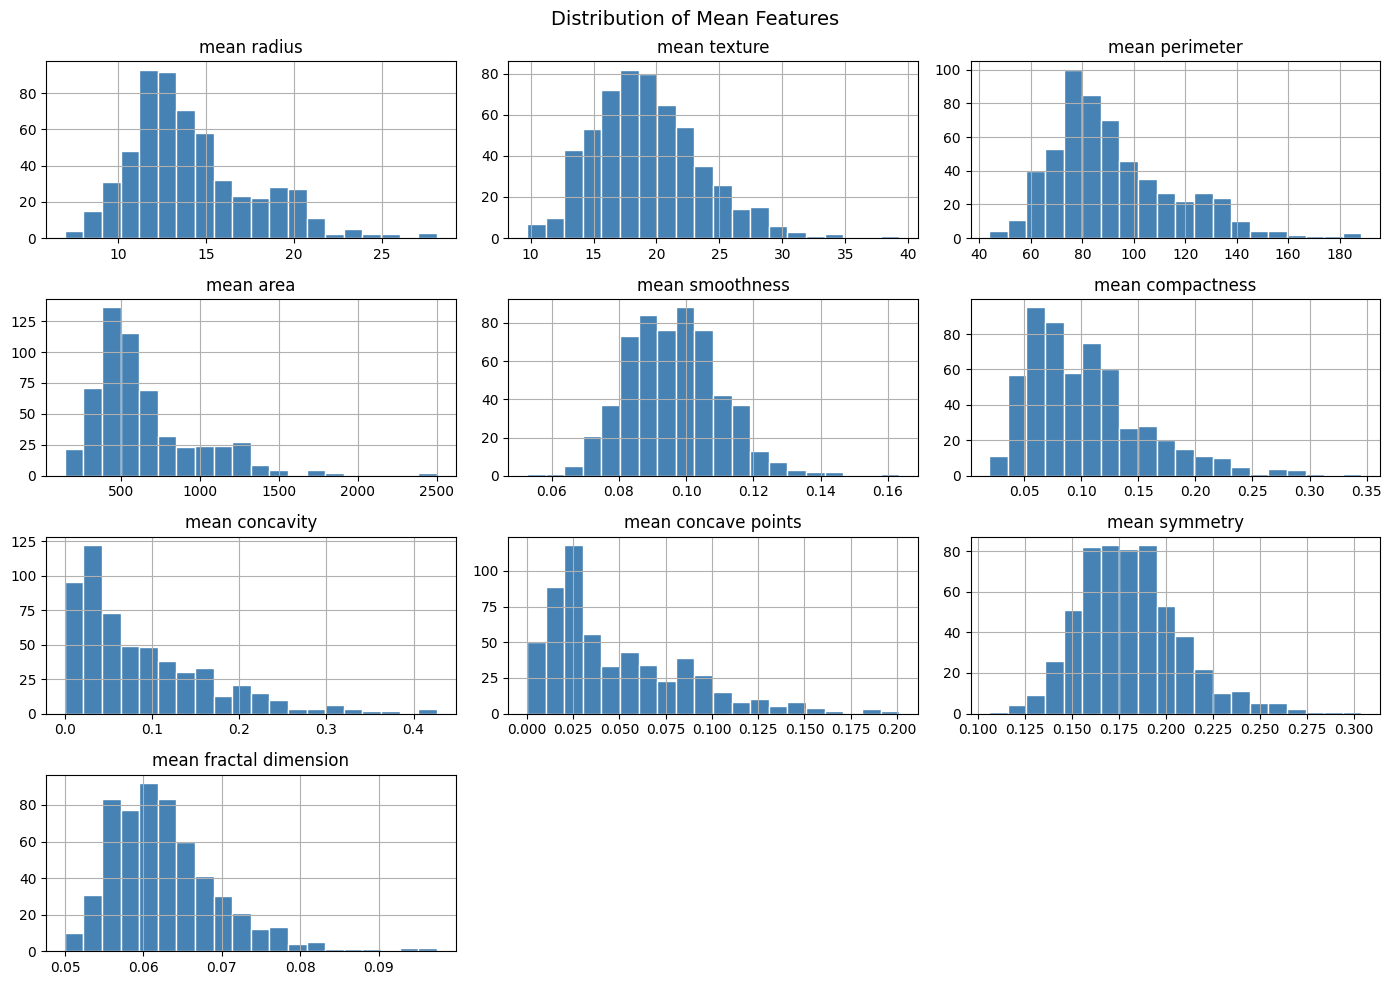

In [18]:
# Plot histogram for all mean columns
mean_cols = ['mean radius', 'mean texture', 'mean perimeter',
             'mean area', 'mean smoothness', 'mean compactness',
             'mean concavity', 'mean concave points',
             'mean symmetry', 'mean fractal dimension']

df[mean_cols].hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Mean Features', fontsize=14)
plt.tight_layout()
plt.show()

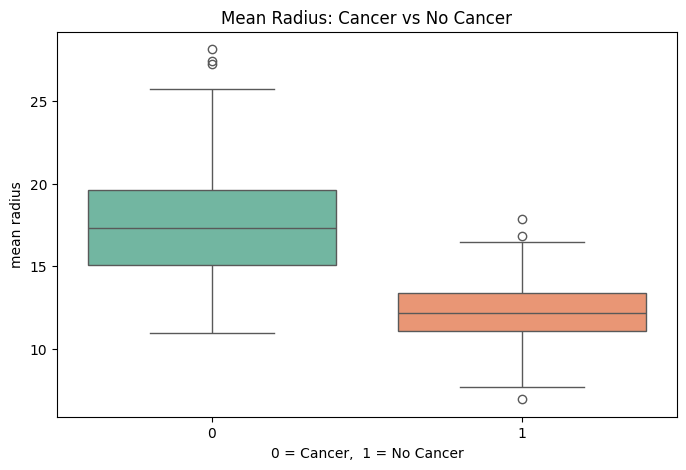

In [20]:
# Boxplot: does radius differ between cancer and no-cancer?
plt.figure(figsize=(8, 5))
sns.boxplot(x='outcome', y='mean radius', data=df, palette='Set2')
plt.title('Mean Radius: Cancer vs No Cancer')
plt.xlabel('0 = Cancer,  1 = No Cancer')
plt.show()

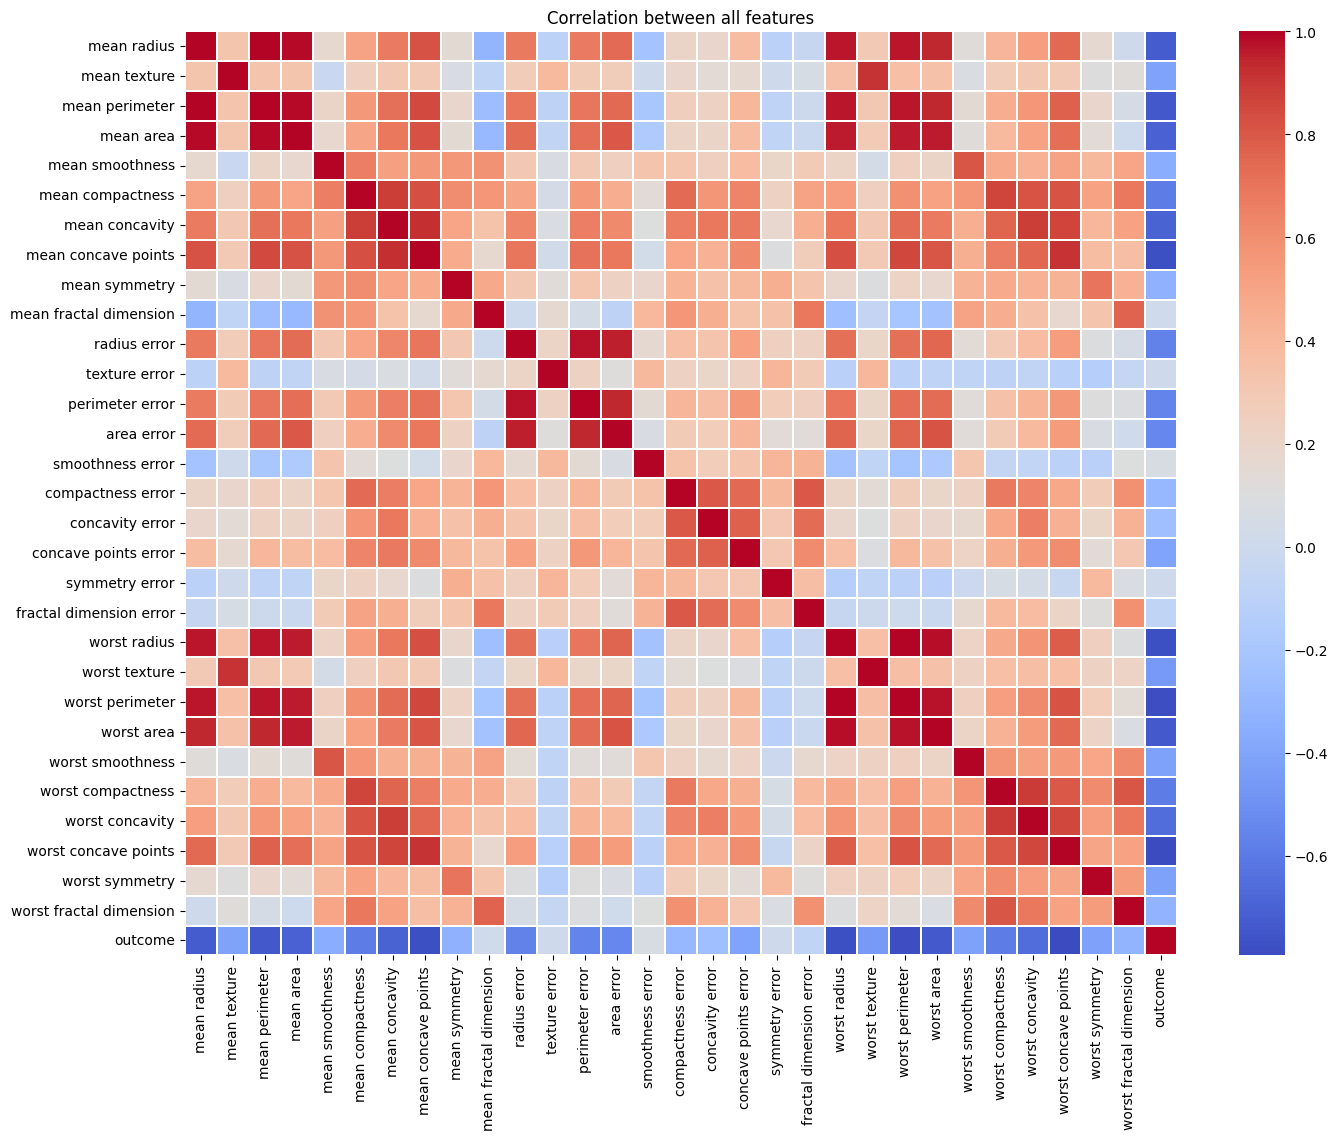

In [21]:
# Which features are related to each other?
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Correlation between all features')
plt.show()

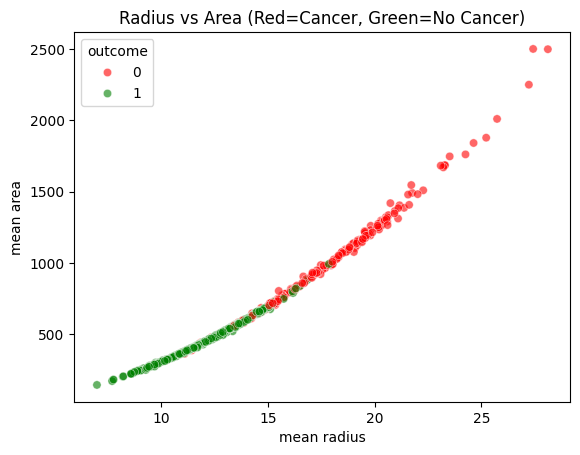

In [22]:
# Do cancer cells have bigger radius AND area?
sns.scatterplot(x='mean radius', y='mean area',
                hue='outcome', data=df,
                palette={0:'red', 1:'green'}, alpha=0.6)
plt.title('Radius vs Area (Red=Cancer, Green=No Cancer)')
plt.show()

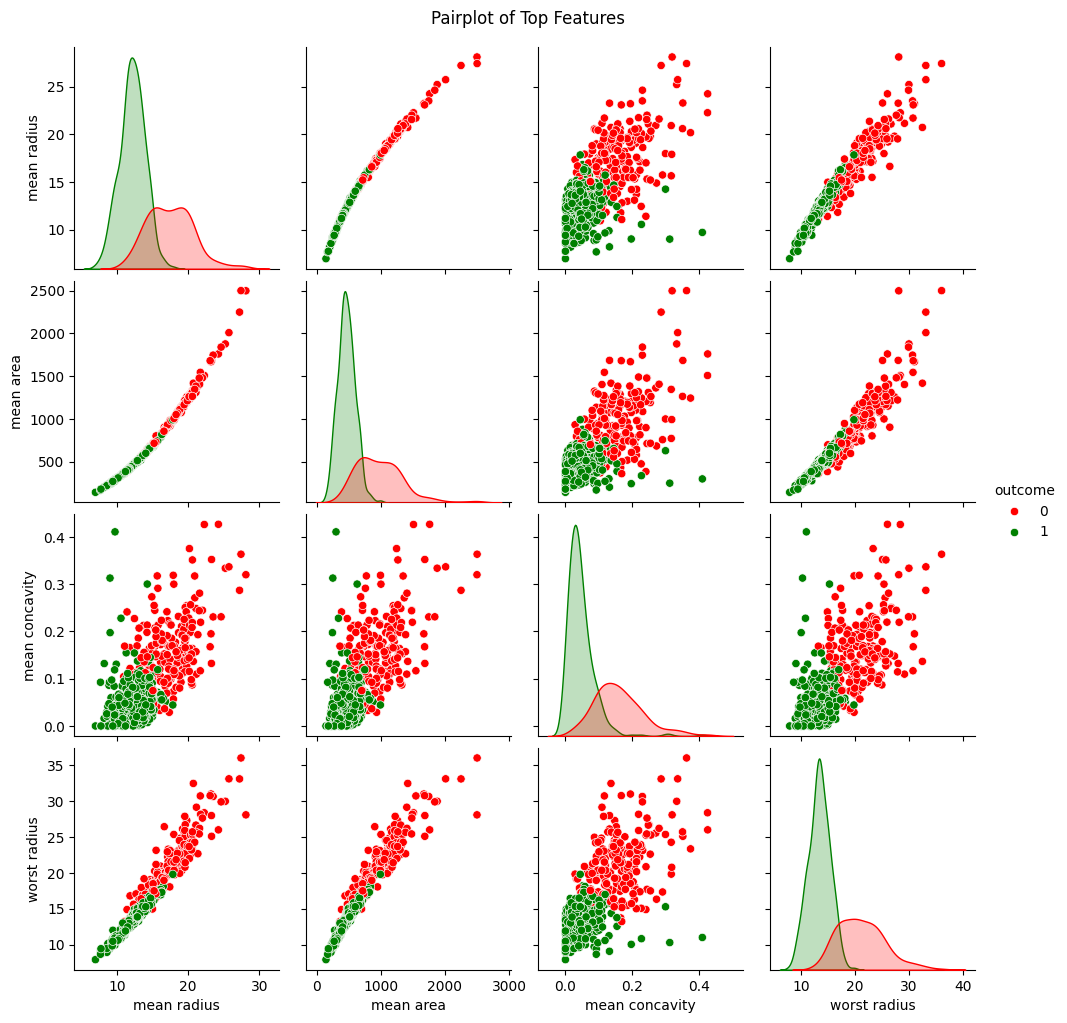

In [23]:
# Compare top 5 features together (takes ~30 seconds to render)
top_cols = ['mean radius', 'mean area', 'mean concavity',
            'worst radius', 'outcome']

sns.pairplot(df[top_cols], hue='outcome',
             palette={0:'red', 1:'green'}, diag_kind='kde')
plt.suptitle('Pairplot of Top Features', y=1.02)
plt.show()

In [24]:
# X = all features (input columns)
# y = what we want to predict (outcome)

# Drop unnecessary columns
X = df.drop(columns='outcome')
y = df['outcome']

print(X.shape)   # (569, 30) → 30 features
print(y.shape)   # (569,)    → 569 labels

(569, 30)
(569,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # so results are same every time you run
)

print(X_train.shape)   # (455, 30)
print(X_test.shape)    # (114, 30)

(455, 30)
(114, 30)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)    # ⚠️ only transform, NOT fit_transform

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)           # Train
    preds = model.predict(X_test)         # Predict
    acc = accuracy_score(y_test, preds)   # Accuracy
    print(f"{name}: {acc*100:.2f}% accuracy")
    print(f"{name} Confusion_Matrix \n {confusion_matrix(y_test,preds)}")

Logistic Regression: 97.37% accuracy
Logistic Regression Confusion_Matrix 
 [[41  2]
 [ 1 70]]
Random Forest: 96.49% accuracy
Random Forest Confusion_Matrix 
 [[40  3]
 [ 1 70]]
SVM: 98.25% accuracy
SVM Confusion_Matrix 
 [[41  2]
 [ 0 71]]
